In [ ]:
# Install dependencies
!pip install pandas matplotlib seaborn -q
print("✅ Dependencies installed")

✅ Dependencies installed


In [ ]:
from google.colab import files
import os

print("📁 Uploading repeat analysis results...")
print("\nSelect file: repeat_detection_summary.csv")
print("Location: ~/nust-genomics-repeat-analysis/results/analysis/")
print()

uploaded = files.upload()

print("\n✅ Files uploaded:")
for filename in uploaded.keys():
    size_kb = os.path.getsize(filename) / 1024
    print(f"  - {filename} ({size_kb:.1f} KB)")

📁 Uploading repeat analysis results...

Select file: repeat_detection_summary.csv
Location: ~/nust-genomics-repeat-analysis/results/analysis/



Saving repeat_detection_summary.csv to repeat_detection_summary.csv

✅ Files uploaded:
  - repeat_detection_summary.csv (0.2 KB)


In [ ]:
import pandas as pd

print("📖 Reading repeat analysis results...\n")

# Read CSV
df = pd.read_csv('repeat_detection_summary.csv')

print("="*80)
print("REPEAT DETECTION ANALYSIS - PRIMATE mtDNA")
print("="*80)
print(df.to_string(index=False))
print("="*80)

# Calculate additional metrics
print("\n📊 COMPARATIVE ANALYSIS:\n")
print(f"Highest Repeat Content: {df.loc[df['Repeat %'].idxmax(), 'Species']} ({df['Repeat %'].max()}%)")
print(f"Most Tandem Repeats: {df.loc[df['Tandem Repeats'].idxmax(), 'Species']} ({df['Tandem Repeats'].max()})")
print(f"Most Homopolymers: {df.loc[df['Homopolymers'].idxmax(), 'Species']} ({df['Homopolymers'].max()})")
print(f"Most Low-Complexity Regions: {df.loc[df['Low-Complexity Regions'].idxmax(), 'Species']} ({df['Low-Complexity Regions'].max()})")

📖 Reading repeat analysis results...

REPEAT DETECTION ANALYSIS - PRIMATE mtDNA
Species  Total BP  Tandem Repeats  Homopolymers  Low-Complexity Regions  Total Repeat BP  Repeat %
  Human     16569             112           114                       4             1324      7.99
  Chimp     16554              96           117                       9             1196      7.22
Gorilla     16412             138           124                      24             1576      9.60

📊 COMPARATIVE ANALYSIS:

Highest Repeat Content: Gorilla (9.6%)
Most Tandem Repeats: Gorilla (138)
Most Homopolymers: Gorilla (124)
Most Low-Complexity Regions: Gorilla (24)


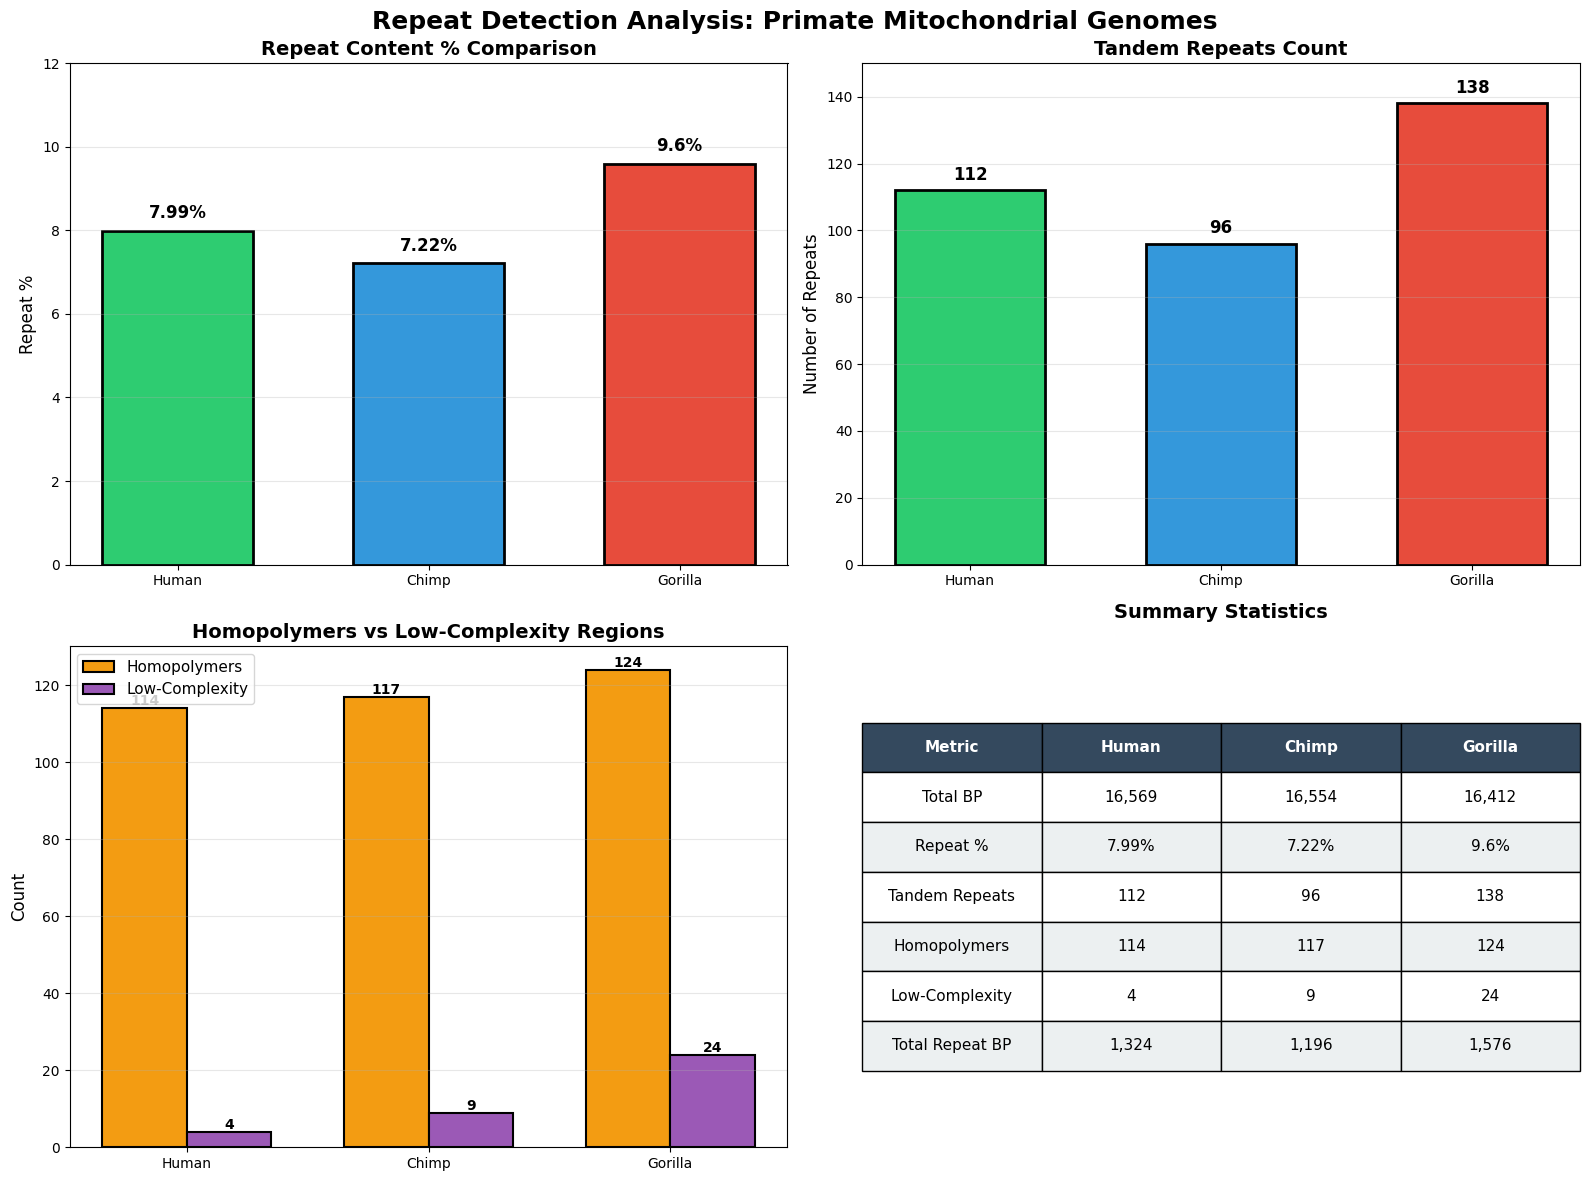

✅ Visualizations created!


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create figure with 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Repeat Detection Analysis: Primate Mitochondrial Genomes',
             fontsize=18, fontweight='bold')

colors = ['#2ecc71', '#3498db', '#e74c3c']
species = df['Species']

# ===== Chart 1: Repeat Content % =====
ax = axes[0, 0]
bars1 = ax.bar(species, df['Repeat %'], color=colors, edgecolor='black', linewidth=2, width=0.6)
ax.set_title('Repeat Content % Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Repeat %', fontsize=12)
ax.set_ylim(0, 12)
ax.grid(axis='y', alpha=0.3)

for bar, val in zip(bars1, df['Repeat %']):
    ax.text(bar.get_x() + bar.get_width()/2., val + 0.2,
            f'{val}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

# ===== Chart 2: Tandem Repeats =====
ax = axes[0, 1]
bars2 = ax.bar(species, df['Tandem Repeats'], color=colors, edgecolor='black', linewidth=2, width=0.6)
ax.set_title('Tandem Repeats Count', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Repeats', fontsize=12)
ax.set_ylim(0, 150)
ax.grid(axis='y', alpha=0.3)

for bar, val in zip(bars2, df['Tandem Repeats']):
    ax.text(bar.get_x() + bar.get_width()/2., val + 2,
            f'{int(val)}', ha='center', va='bottom', fontweight='bold', fontsize=12)

# ===== Chart 3: Homopolymers & Low-Complexity =====
ax = axes[1, 0]
x = np.arange(len(species))
width = 0.35

bars3a = ax.bar(x - width/2, df['Homopolymers'], width, label='Homopolymers',
                color='#f39c12', edgecolor='black', linewidth=1.5)
bars3b = ax.bar(x + width/2, df['Low-Complexity Regions'], width, label='Low-Complexity',
                color='#9b59b6', edgecolor='black', linewidth=1.5)

ax.set_title('Homopolymers vs Low-Complexity Regions', fontsize=14, fontweight='bold')
ax.set_ylabel('Count', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(species)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars3a, bars3b]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# ===== Chart 4: Summary Table =====
ax = axes[1, 1]
ax.axis('off')

summary_data = [
    ['Metric', 'Human', 'Chimp', 'Gorilla'],
    ['Total BP', f'{df.loc[0, "Total BP"]:,}', f'{df.loc[1, "Total BP"]:,}', f'{df.loc[2, "Total BP"]:,}'],
    ['Repeat %', f'{df.loc[0, "Repeat %"]}%', f'{df.loc[1, "Repeat %"]}%', f'{df.loc[2, "Repeat %"]}%'],
    ['Tandem Repeats', f'{df.loc[0, "Tandem Repeats"]}', f'{df.loc[1, "Tandem Repeats"]}', f'{df.loc[2, "Tandem Repeats"]}'],
    ['Homopolymers', f'{df.loc[0, "Homopolymers"]}', f'{df.loc[1, "Homopolymers"]}', f'{df.loc[2, "Homopolymers"]}'],
    ['Low-Complexity', f'{df.loc[0, "Low-Complexity Regions"]}', f'{df.loc[1, "Low-Complexity Regions"]}', f'{df.loc[2, "Low-Complexity Regions"]}'],
    ['Total Repeat BP', f'{df.loc[0, "Total Repeat BP"]:,}', f'{df.loc[1, "Total Repeat BP"]:,}', f'{df.loc[2, "Total Repeat BP"]:,}']
]

table = ax.table(cellText=summary_data, cellLoc='center', loc='center',
                colWidths=[0.25, 0.25, 0.25, 0.25])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)

# Style header row
for i in range(4):
    table[(0, i)].set_facecolor('#34495e')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Alternate row colors
for i in range(1, len(summary_data)):
    for j in range(4):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#ecf0f1')
        else:
            table[(i, j)].set_facecolor('#ffffff')

ax.set_title('Summary Statistics', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('repeat_analysis_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Visualizations created!")

In [ ]:
from google.colab import files

print("📥 Downloading analysis visualizations...\n")

files.download('repeat_analysis_comparison.png')

print("✅ Download started!")
print("\n📍 File will appear in your Downloads folder:")
print("   repeat_analysis_comparison.png")

📥 Downloading analysis visualizations...



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download started!

📍 File will appear in your Downloads folder:
   repeat_analysis_comparison.png
